In [27]:
import numpy as np
import os
import mat73
import seaborn as sb
import pingouin as pg
import PcmPy as pcm
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from scipy.stats import ttest_1samp
import pickle
import pandas as pd
from statsmodels.stats.anova import AnovaRM
from matplotlib.cm import ScalarMappable
from matplotlib.patches import Patch
from sklearn.preprocessing import MinMaxScaler
import nibabel as nb
import nitools as nt
from pathlib import Path
import sys
from SensoriMotorPrediction.vis import plot_rdm, plot_surf
import SensoriMotorPrediction.globals as gl

In [28]:
experiment = 'smp2'
H = 'L'
epoch = 'plan'
rois = gl.rois['ROI']
glm = 12

# Representational geometry during preparation (Fig. 3c)

Mean crossnobis dissimilarity against 0 (one-sided t-test):
SMA: tval=3.5010671094999073, pval=0.0019530226706477509
PMd: tval=4.598273847949548, pval=0.00024963097770992716
PMv: tval=5.3808301566361045, pval=6.25938114432965e-05
M1: tval=4.899815837755327, pval=0.00014509603765901948
S1: tval=7.019441292795594, pval=4.537072556005718e-06
SPLa: tval=4.418617091916282, pval=0.000346742520476346
SPLp: tval=6.069299768949967, pval=1.986392417741581e-05


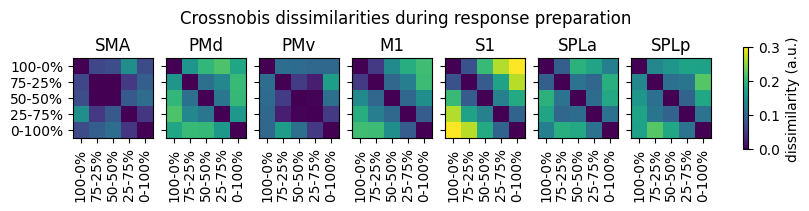

In [29]:
vmin, vmax = 0, .3

fig, axs = plt.subplots(1, len(rois), figsize=(8, 2),sharex=True, sharey=True, constrained_layout=True)
tr_null_plan, tr_pot_plan = [], []
print('Mean crossnobis dissimilarity against 0 (one-sided t-test):')
for r, roi in enumerate(rois):
    G = np.load(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, f'G_obs.plan.glm{glm}.{H}.{roi}.npy'))
    tr_null_plan.append(np.trace(G, axis1=1, axis2=2))
    D = pcm.G_to_dist(G)
    fig, axs = plot_rdm(fig, axs, r, D, ['100-0%', '75-25%', '50-50%', '25-75%', '0-100%'], vmin=vmin, vmax=vmax, sqrt=True, source=roi)
    axs[r].set_title(roi)
cax = axs[-1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=.008)
cbar.set_label('dissimilarity (a.u.)')
fig.suptitle('Crossnobis dissimilarities during response preparation')
fig.savefig(os.path.join('figures', 'crossnobis.plan.pdf'))
plt.show()

# log-Bayes factor for expectation and uncertainty (Fig. 3d, see asterisks below bars)

T  dof alternative     p-val         CI95%  \
roi  component                                                               
M1   expectation T-test  2.446785   13     greater  0.014695   [5.97, inf]   
     uncertainty T-test  1.420972   13     greater  0.089433  [-0.47, inf]   
PMd  expectation T-test  3.697104   13     greater  0.001342   [5.15, inf]   
     uncertainty T-test  2.108148   13     greater  0.027496   [4.07, inf]   
PMv  expectation T-test  1.618486   13     greater  0.064776  [-0.12, inf]   
     uncertainty T-test  2.124096   13     greater  0.026710   [0.56, inf]   
S1   expectation T-test  3.397400   13     greater  0.002383  [34.48, inf]   
     uncertainty T-test  2.164677   13     greater  0.024804   [0.56, inf]   
SMA  expectation T-test  1.081856   13     greater  0.149488  [-0.58, inf]   
     uncertainty T-test  1.570233   13     greater  0.070186  [-0.31, inf]   
SPLa expectation T-test  3.034924   13     greater  0.004787   [2.44, inf]   
     uncertainty T-test  1.675392   13     greater  0.058864  [-0.99, inf]   
SPLp expectation T-test  3.251405   13     greater  0.003156   [3.25, inf]   
     uncertainty T-test  2.985036   13     greater  0.005269   [6.47, inf]   

                          cohen-d    BF10     power  
roi  component                                       
M1   expectation T-test  0.653931   4.765  0.749094  
     uncertainty T-test  0.379771   1.238  0.382850  
PMd  expectation T-test  0.988093  33.877  0.967881  
     uncertainty T-test  0.563426   2.926  0.637503  
PMv  expectation T-test  0.432559    1.55  0.455756  
     uncertainty T-test  0.567689   2.992  0.643139  
S1   expectation T-test  0.907993  20.947  0.941587  
     uncertainty T-test  0.578534   3.167  0.657335  
SMA  expectation T-test  0.289138   0.886  0.267945  
     uncertainty T-test  0.419662   1.464  0.437710  
SPLa expectation T-test  0.811117  11.768  0.890010  
     uncertainty T-test  0.447767    1.66  0.477150  
SPLp expectation T-test  0.868974  16.589  0.923736  
     uncertainty T-test  0.797784  10.879  0.880908

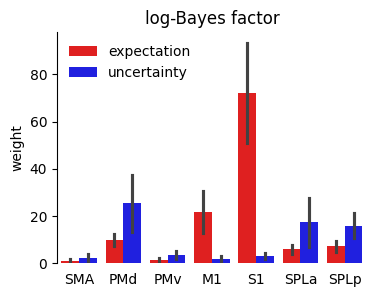

In [30]:
df = pd.read_csv(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, 'component_model.BOLD.tsv'), sep='\t')
df = df[(df.epoch=='plan') & (df.Hem==H) & (df.glm==glm) & (df.label=='none')]
fig, ax = plt.subplots(figsize=(4, 3))
sb.barplot(ax=ax, data=df, x='roi', y='BF', hue='component', palette=['red', 'blue'], errorbar='se')
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.set_xlabel('')
ax.set_ylabel('weight')
ax.tick_params(axis='x', bottom=False,)
ax.legend(title=None, frameon=False)
ax.set_title('log-Bayes factor')
results = df.groupby(['roi', 'component']).BF.apply(lambda x: pg.ttest(x, 0, alternative='greater'))
display(results)
plt.show()

# Standardised weight of expectation and uncertainty (Fig. 3d)

,,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,hedges
roi,,,,,,,,,,,,
M1,0,component,expectation,uncertainty,True,True,2.933876,13.0,greater,0.005813,10.039,0.992461
PMd,0,component,expectation,uncertainty,True,True,-0.647931,13.0,greater,0.735846,0.648,-0.192257
PMv,0,component,expectation,uncertainty,True,True,-1.108019,13.0,greater,0.856034,0.907,-0.413870
S1,0,component,expectation,uncertainty,True,True,4.056132,13.0,greater,0.000680,60.233,1.507573
SMA,0,component,expectation,uncertainty,True,True,-0.426145,13.0,greater,0.661513,0.585,-0.133422
SPLa,0,component,expectation,uncertainty,True,True,-0.717345,13.0,greater,0.757074,0.675,-0.237032
SPLp,0,component,expectation,uncertainty,True,True,-0.984388,13.0,greater,0.828554,0.816,-0.367927


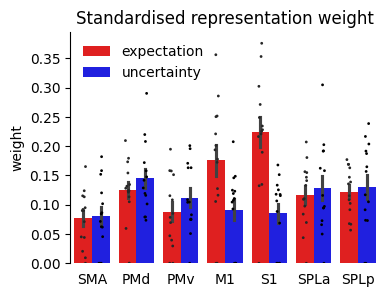

In [31]:
fig, ax = plt.subplots(figsize=(4, 3))
df['norm_weight'] = np.sqrt(df['weight'] / df['noise'])
sb.barplot(ax=ax, data=df, x='roi', y='norm_weight', hue='component', palette=['red', 'blue'], errorbar='se')
sb.stripplot(ax=ax, data=df, x='roi', y='norm_weight', hue='component', size=2, color='black', jitter=.1, dodge=True, legend=False)
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.set_xlabel('')
ax.set_ylabel('weight')
ax.tick_params(axis='x', bottom=False,)
ax.legend(title=None, frameon=False)
ax.set_title('Standardised representation weight')
res = df.groupby('roi').apply(lambda g: pg.pairwise_tests(data=g, dv='weight', within='component', subject='participant_id', alternative='greater'))
display(res)
plt.show()

# Expectation relative to expectation+uncertainty in M1-S1 vs. premotor-parietal areas (Fig. 3e)

M1-S1 vs. premotor parietal (one-sided t-test): tval=4.974, pval=0.000


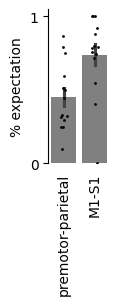

In [32]:
df_cluster = df.groupby(['cluster', 'participant_id', 'component']).mean(numeric_only=True).reset_index()
df_exp = df_cluster[df_cluster['component']=='expectation']
df_sum = df_cluster.groupby(['cluster', 'participant_id']).sum(numeric_only=True).reset_index()
df_ratio = df_exp.copy()
df_ratio['ratio'] = df_exp['weight'].to_numpy() / df_sum['weight'].to_numpy()
df_ratio['cluster'] = pd.Categorical(df_ratio['cluster'], categories=['premotor-parietal','M1-S1'],ordered=True)

fig, ax = plt.subplots(figsize=(.8, 2))

sb.barplot(data=df_ratio, x='cluster', y='ratio', errorbar='se', color='grey')
sb.stripplot(data=df_ratio, x='cluster', y='ratio', size=2, color='black', jitter=.1, dodge=True, legend=False, order=['premotor-parietal','M1-S1'])
ax.spines[['bottom', 'right', 'top']].set_visible(False)
ax.tick_params(axis='x', bottom=False,)
ax.set_xlabel('')
ax.set_yticks((0, 1))
ax.set_xticklabels(['premotor-parietal', 'M1-S1'], rotation=90)
ax.set_ylabel('% expectation')

m1_s1 = df_ratio[df_ratio['cluster']=='M1-S1'].ratio.to_numpy()
pmd_spl = df_ratio[df_ratio['cluster']=='premotor-parietal'].ratio.to_numpy()
tval, pval = ttest_1samp(m1_s1 - pmd_spl, popmean=0, alternative='greater')
print(f'M1-S1 vs. premotor parietal (one-sided t-test): tval={tval:.3f}, pval={pval:.3f}')
plt.show()

# Expectation and uncertainty weight projected on inflated surface (searchlight analysis, Fig. 3f)

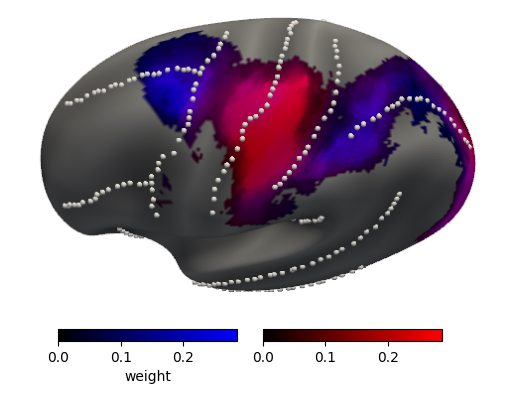

In [33]:
mclip = .2
threshold = .05 / mclip
scaler = MinMaxScaler()

gifti = nb.load(os.path.join('data', 'encoding', f'searchlight.var_expl.plan.{H}.func.gii'))
data = nt.get_gifti_data_matrix(gifti)
raw_max = np.nanmax(data)
data = data / raw_max#scaler.fit_transform(data)
raw_min = 0 #scaler.inverse_transform([[threshold * mclip, threshold * mclip]])[0,0]
data = np.clip(data / mclip, 0, 1)

sulc = nt.get_gifti_data_matrix(nb.load(os.path.join('atlases', 'fs_LR.32k.LR.sulc.dscalar.gii')))
sulc = sulc[:len(data)]
sulc_norm = MinMaxScaler((0.3, 0.7)).fit_transform(sulc.reshape(-1, 1)).flatten()

rgba = np.zeros((len(sulc_norm), 4))
rgba[:, 0] = sulc_norm  # red = grey
rgba[:, 1] = sulc_norm  # green = grey
rgba[:, 2] = sulc_norm  # blue = grey
rgba[:, 3] = 1.0        # opaque background

overlay_mask = (data[:, 0] >= threshold) | (data[:, 1] >= threshold)

rgba[overlay_mask, 0] = data[overlay_mask, 0]  # red
rgba[overlay_mask, 1] = 0                    # green stays off for 2-color blend
rgba[overlay_mask, 2] = data[overlay_mask, 1]  # blue
rgba[overlay_mask, 3] = 1.0                     # alpha: opaque overlay
rgba[~overlay_mask, 3] = 1.0                    # still show grey background

fig, ax = plt.subplots()
fig, ax = plot_surf(fig, ax, rgba, H, cmap=None, vmin=None, vmax=None, overlay='rgb')

blue_half = LinearSegmentedColormap.from_list("blue_half", ["black", "blue"])
neg_norm = Normalize(vmin=raw_min, vmax=raw_max)
sm_neg = ScalarMappable(norm=neg_norm, cmap=blue_half)

red_half = LinearSegmentedColormap.from_list("red_half", ["black", "red"])
pos_norm = Normalize(vmin=raw_min, vmax=raw_max)
sm_pos = ScalarMappable(norm=pos_norm, cmap=red_half)

cax_neg = fig.add_axes([0.20, 0.10, 0.28, 0.025])  # left (blue)
cax_pos = fig.add_axes([0.52, 0.10, 0.28, 0.025])  # right (red)

cbar_neg = fig.colorbar(sm_neg, cax=cax_neg, orientation='horizontal')
cbar_pos = fig.colorbar(sm_pos, cax=cax_pos, orientation='horizontal')

cbar_neg.set_label('weight')

plt.show()

# Expectation weight in LFPs and spiking activity (Fig. 3g)

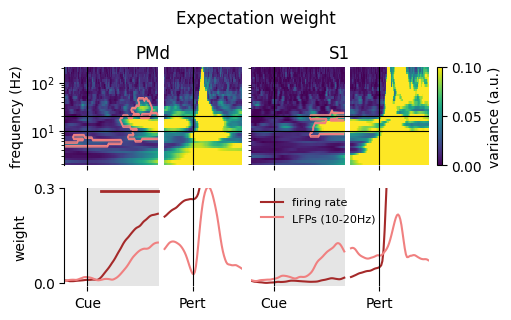

In [34]:
rois = ['PMd', 'S1']

fig, axs_ = plt.subplots(2, len(rois)+1, sharex='col', figsize=(5, 3), gridspec_kw={"width_ratios": [80] * len(rois) + [2]}, constrained_layout=True)

axs = axs_[:, :-1]
ax_c = axs_[:, -1]

freq1, freq2 = 10, 20
cfg = mat73.loadmat(os.path.join('data','LFPs','cfg.mat'))['cfg']
foi = cfg['foi']
freq_mask = (foi > freq1) & (foi < freq2)
t_cue = np.linspace(0, gl.cuePost - 1, gl.cuePost)
t_pert = np.linspace(gl.pertPre, gl.pertPost - 1, gl.pertPost - gl.pertPre) + 5
t = np.concatenate((t_cue, t_pert))

vmin, vmax = 0, .1
color = [['darkred', 'navy'], ['lightcoral', 'lightblue']]
rois = ['PMd', 'S1']
model = 'Expectation'
for r, roi in enumerate(rois):
    weight_lfp = np.load(os.path.join('data', 'encoding', f'weight.lfp.{roi}.plan.npy'))[..., 0].mean(axis=0)
    weight_lfp_band = weight_lfp[freq_mask].mean(axis=0)
    sig_lfp1 = np.load(os.path.join('data', 'encoding', f'significant_bf.lfp.Cue.{roi}.plan.npy'))
    sig_lfp1 = sig_lfp1[..., 0]
    weight_lfp1 = weight_lfp[:, :gl.cuePost]
    weight_lfp2 = weight_lfp[:, gl.pertPre:]
    weight_lfp_band1 = weight_lfp_band[:gl.cuePost]
    weight_lfp_band2 = weight_lfp_band[gl.pertPre:]
    h = axs[0, r].pcolormesh(t_cue, foi, weight_lfp1, vmin=vmin, vmax=vmax, cmap='viridis')
    axs[0, r].contour(t_cue, foi, sig_lfp1, levels=1, colors='lightcoral', linewidths=1)
    axs[0, r].pcolormesh(t_pert, foi, weight_lfp2, vmin=vmin, vmax=vmax, cmap='viridis')
    axs[0, r].set_yscale('log')
    axs[0, r].set_title(roi)
    axs[0, r].axhline(freq1, color='k', lw='.8')
    axs[0, r].axhline(freq2, color='k', lw='.8')
    axs[0, r].set_ylabel('frequency (Hz)') if r==0 else None
    weight_spk = np.load(os.path.join('data', 'encoding', f'weight.spk.{roi}.plan.npy'))[..., 0].mean(axis=0)
    weight_spk1 = weight_spk[:gl.cuePost]
    weight_spk2 = weight_spk[gl.pertPre:]
    sig_spk1 = np.load(os.path.join('data', 'encoding', f'significant_bf.spk.Cue.{roi}.plan.npy'))
    sig_spk1 = sig_spk1[..., 0]
    sig_spk1[sig_spk1<1] = np.nan
    sig_spk1[sig_spk1==1] = .29
    axs[1, r].plot(t_cue, sig_spk1, color='brown', lw=2)
    axs[1, r].plot(t_cue, weight_spk1, color='brown', label='firing rate')
    axs[1, r].plot(t_pert, weight_spk2, color='brown')
    axs[1, r].plot(t_cue, weight_lfp_band1, color='lightcoral', label='LFPs (10-20Hz)')
    axs[1, r].plot(t_pert, weight_lfp_band2, color='lightcoral')
    axs[1, r].axvspan(gl.cueIdx, gl.cuePost, color='grey', alpha=.2, lw=0)
    axs[1, r].set_ylim([-.01, .3])
    axs[1, r].set_yticks((0, .3))
    axs[1, r].spines['left'].set_bounds(0, .3)
    axs[1, r].set_ylabel('weight') if r==0 else None
    for i in range(2):
        axs[i, r].axvline(gl.cueIdx, color='k', lw='.8')
        axs[i, r].axvline(gl.pertIdx, color='k', lw='.8')
        axs[i, r].set_xticks([gl.cueIdx, gl.pertIdx])
        axs[i, r].set_xticklabels(['Cue', 'Pert'])
        axs[i, r].set_yticks([]) if r>0 else None
        axs[i, r].spines[['bottom', 'right', 'top']].set_visible(False) if r==0 else axs[i, r].spines[['bottom', 'right', 'top', 'left']].set_visible(False)

axs[1, 1].legend(frameon=False, ncol=1, fontsize=8, loc='upper left')

fig.colorbar(h, cax=ax_c[0], label='variance (a.u.)')
for ax in ax_c[1:]:
    ax.remove()

fig.suptitle(f'{model} weight', va='center')

plt.show()

# Weight of expectation in LFPs vs. spiking activity and PMd vs. S1

,Source,SS,DF,MS,F,p-unc,np2
0,modality,0.038826,1.0,0.038826,1.097377,0.300089,0.022351
1,roi,0.807470,1.0,0.807470,22.822246,0.000017,0.322247
2,modality * roi,0.910036,1.0,0.910036,25.721161,0.000006,0.348898
3,Residual,1.698279,48.0,0.035381,NaN,NaN,NaN


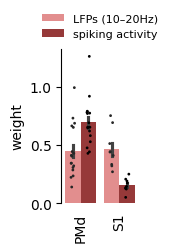

In [35]:
df_exp = pd.DataFrame()
for mod in ['lfp', 'spk']:
    df_ephys = pd.read_csv(os.path.join('data', 'encoding', f'weight.{mod}.10-20Hz.tsv'), sep='\t')
    df_ephys = df_ephys[((df_ephys['roi']=='PMd') | (df_ephys['roi']=='S1')) & (df_ephys['epoch']=='plan')]
    df_ephys['weight_norm'] = np.sqrt(df_ephys['weight'] / df_ephys['noise'])
    df_ephys['session'] = df_ephys['session'].astype(str) + df_ephys['monkey']
    df_exp_tmp = df_ephys[df_ephys['component']=='expectation'].reset_index(drop=True)
    df_exp_tmp['modality'] = mod
    df_exp = pd.concat([df_exp, df_exp_tmp])

fig, ax = plt.subplots(figsize=(1, 2))

sb.barplot(data=df_exp, x='roi', y='weight_norm', hue='modality', errorbar='se', ax=ax, palette=['lightcoral', 'brown'], color='grey')
sb.stripplot(data=df_exp, x='roi', y='weight_norm', hue='modality', ax=ax, size=2, color='k', jitter=.1, dodge=True, legend=False)
ax.spines[['bottom', 'right', 'top']].set_visible(False)
ax.tick_params(axis='x', bottom=False,)
ax.set_xlabel('')
ax.set_xticks((0, 1))
ax.set_xticklabels(['PMd', 'S1'], rotation=90)
ax.set_ylabel('weight')
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ['LFPs (10–20Hz)', 'spiking activity'], frameon=False, title=False,
          fontsize=8, bbox_to_anchor=(.5, 1), loc='lower center')

aov = pg.anova(
    data=df_exp,
    dv='weight_norm',
    between=['modality', 'roi'],
    detailed=True
)

display(aov)

plt.show()